In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

Full: α=3.0684, θ=0.3259, media=1.0000, KS=0.0075, p=0.0000
Erdős-Rényi: α=3.0699, θ=0.3257, media=1.0000, KS=0.0076, p=0.0000
Barabási-Albert: α=3.0715, θ=0.3256, media=1.0000, KS=0.0072, p=0.0000
Watts-Strogatz: α=3.0670, θ=0.3261, media=1.0000, KS=0.0075, p=0.0000


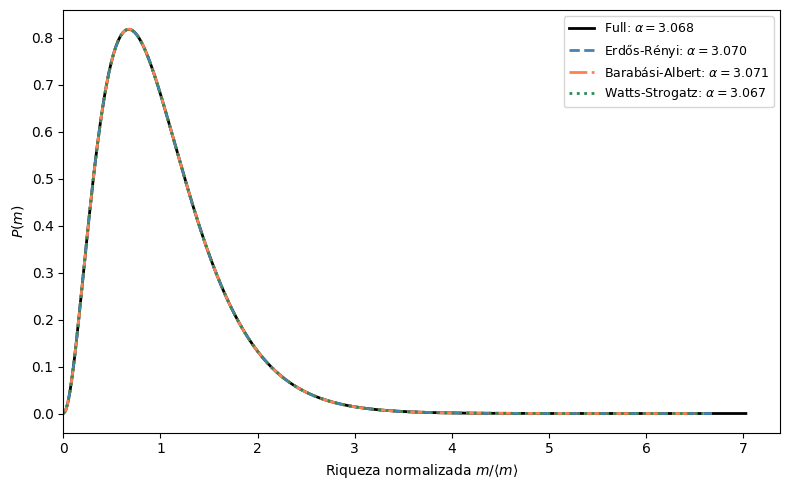

In [3]:
from scipy.stats import gamma, kstest
import numpy as np
import matplotlib.pyplot as plt

M = 5e4
N = 500

datasets = {
    'Full':             np.load('Full/Pm_lamb0.4.npy') / (M/N),
    'Erdős-Rényi':      np.load('Erdos-Renyi/Pm_lamb0.4.npy') / (M/N),
    'Barabási-Albert':  np.load('Barabasi-Albert/Pm_lamb0.4.npy') / (M/N),
    'Watts-Strogatz':   np.load('Watts-Strogatz/Pm_lamb0.4.npy') / (M/N),
}

colors     = ['black', 'steelblue', 'coral', 'seagreen']
linestyles = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=(8, 5))

for (label, data), color, ls in zip(datasets.items(), colors, linestyles):
    data_flat = data.flatten()
    alpha, loc, scale = gamma.fit(data_flat, floc=0)

    x_fit = np.linspace(0, data.max(), 300)
    y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)

    ax.plot(x_fit, y_fit, color=color, lw=2, linestyle=ls,
            label=fr'{label}: $\alpha={alpha:.3f}$')

    stat, p = kstest(data_flat, 'gamma', args=(alpha, 0, scale))
    print(f"{label}: α={alpha:.4f}, θ={scale:.4f}, media={alpha*scale:.4f}, KS={stat:.4f}, p={p:.4f}")

ax.set_xlim(left=0)
ax.set_xlabel('Riqueza normalizada $m/\\langle m \\rangle$')
ax.set_ylabel('$P(m)$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

M = 5e4
N = 500

lambdas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

redes = {
    'Full':             'Full',
    'Erdos-Renyi':      'Erdos-Renyi',
    'Barabasi-Albert':  'Barabasi-Albert',
    'Watts-Strogatz':   'Watts-Strogatz',
    'Communities':      'Comunities',
}

#-----------------------------------INDICES--------------------------------------

def gini(x):
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * x) / (n * np.sum(x))) - (n + 1) / n

def theil_normalizado(x):
    x = x[x > 0]
    n = len(x)
    mu = x.mean()
    T = np.sum((x / mu) * np.log(x / mu)) / n
    T_max = np.log(n)
    return T / T_max

#-----------------------------------CALCULO--------------------------------------

for nombre, carpeta in redes.items():
    print(f"\n{'='*45}")
    print(f"  Red: {nombre}")
    print(f"{'='*45}")
    print(f"{'λ':<6} {'Gini':>10} {'Theil norm.':>14}")
    print("-" * 32)

    for lamb in lambdas:
        data = np.load(f'{carpeta}/Pm_lamb{lamb:.1f}.npy') / (M/N)
        data_flat = data.flatten()

        g = gini(data_flat)
        t = theil_normalizado(data_flat)
        print(f"{lamb:<6.1f} {g:>10.4f} {t:>14.4f}")


  Red: Full
λ            Gini    Theil norm.
--------------------------------
0.0        0.4996         0.0274
0.1        0.4446         0.0212
0.2        0.3965         0.0166
0.3        0.3530         0.0131
0.4        0.3121         0.0101
0.5        0.2734         0.0077
0.6        0.2351         0.0057
0.7        0.1962         0.0040
0.8        0.1550         0.0025
0.9        0.1061         0.0011

  Red: Erdos-Renyi
λ            Gini    Theil norm.
--------------------------------
0.0        0.4996         0.0274
0.1        0.4445         0.0212
0.2        0.3965         0.0166
0.3        0.3528         0.0130
0.4        0.3121         0.0101
0.5        0.2735         0.0077
0.6        0.2350         0.0057
0.7        0.1962         0.0040
0.8        0.1549         0.0025
0.9        0.1061         0.0011

  Red: Barabasi-Albert
λ            Gini    Theil norm.
--------------------------------
0.0        0.4990         0.0273
0.1        0.4442         0.0212
0.2        0.3964  